# Italy Flights Dataset — Exploratory Data Analysis

Dataset: `italy_flights_20k.parquet`  
Features: `track_id`, `lon`, `lat`, `alt`, `timestamp`  
Sampling frequency: 10 seconds

## 1. Imports & Load Data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

PARQUET_PATH = "../data/data.parquet"
MIN_LENGTH   = 200   # minimum steps to keep a flight
SEED         = 42
rng          = np.random.default_rng(SEED)

In [35]:
df = pd.read_parquet(PARQUET_PATH)

# Convert unix timestamp → datetime (UTC)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)

print(f"Total rows : {len(df):,}")
print(f"Columns    : {list(df.columns)}")
df.head()

Total rows : 1,403,610
Columns    : ['track_id', 'lon', 'lat', 'alt', 'timestamp', 'datetime']


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50+00:00
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00+00:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10+00:00
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20+00:00
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30+00:00


## 2. Dataset Overview

In [36]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== Null counts ===")
print(df.isnull().sum())
print()
print("=== Numeric summary ===")
df[["lon","lat","alt"]].describe().round(3)

=== dtypes ===
track_id                  object
lon                      float64
lat                      float64
alt                      float64
timestamp                  int64
datetime     datetime64[ns, UTC]
dtype: object

=== Null counts ===
track_id     0
lon          0
lat          0
alt          0
timestamp    0
datetime     0
dtype: int64

=== Numeric summary ===


,lon,lat,alt
count,1403610.000,1403610.000,1403610.000
mean,31.969,35.923,9557.888
std,2.230,2.979,3302.073
min,28.000,24.002,-365.760
25%,30.092,33.558,9403.080
50%,31.833,35.754,10668.000
75%,33.780,38.894,11574.780
max,44.270,40.000,38496.240


In [37]:
n_flights = df["track_id"].nunique()
date_min  = df["datetime"].min()
date_max  = df["datetime"].max()

print(f"Unique flights : {n_flights:,}")
print(f"Date range     : {date_min.date()}  →  {date_max.date()}")
print(f"Lon range      : [{df['lon'].min():.3f}, {df['lon'].max():.3f}]")
print(f"Lat range      : [{df['lat'].min():.3f}, {df['lat'].max():.3f}]")
print(f"Alt range (m)  : [{df['alt'].min():.1f}, {df['alt'].max():.1f}]")

Unique flights : 11,495
Date range     : 2021-01-04  →  2022-03-28
Lon range      : [28.000, 44.270]
Lat range      : [24.002, 40.000]
Alt range (m)  : [-365.8, 38496.2]


## 3. Flight-Level Statistics

In [38]:
flight_len = df.groupby("track_id").size().rename("n_steps")

print("=== Flight length (steps) ===")
print(flight_len.describe().round(1))
print()
print(f"Flights with < {MIN_LENGTH} steps : {(flight_len < MIN_LENGTH).sum():,}")
print(f"Flights with >= {MIN_LENGTH} steps : {(flight_len >= MIN_LENGTH).sum():,}")

=== Flight length (steps) ===
count    11495.0
mean       122.1
std         88.0
min          1.0
25%         55.0
50%         98.0
75%        173.0
max        359.0
Name: n_steps, dtype: float64

Flights with < 200 steps : 9,134
Flights with >= 200 steps : 2,361


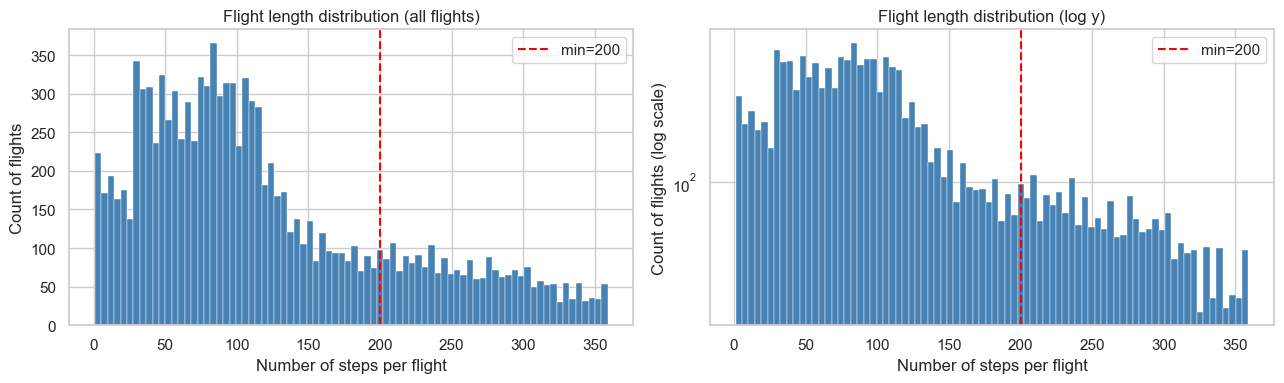

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution
axes[0].hist(flight_len.values, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(MIN_LENGTH, color="red", linestyle="--", label=f"min={MIN_LENGTH}")
axes[0].set_xlabel("Number of steps per flight")
axes[0].set_ylabel("Count of flights")
axes[0].set_title("Flight length distribution (all flights)")
axes[0].legend()

# Log-scale to reveal short-flight spike
axes[1].hist(flight_len.values, bins=80, color="steelblue", edgecolor="white", linewidth=0.3, log=True)
axes[1].axvline(MIN_LENGTH, color="red", linestyle="--", label=f"min={MIN_LENGTH}")
axes[1].set_xlabel("Number of steps per flight")
axes[1].set_ylabel("Count of flights (log scale)")
axes[1].set_title("Flight length distribution (log y)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Temporal Coverage

/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_98299/373237508.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  flight_start["month"]      = flight_start["datetime"].dt.to_period("M").astype(str)
/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_98299/373237508.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(monthly.index, rotation=45, ha="right")
/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_98299/373237508.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(dow.index, rotation=30, ha="right")


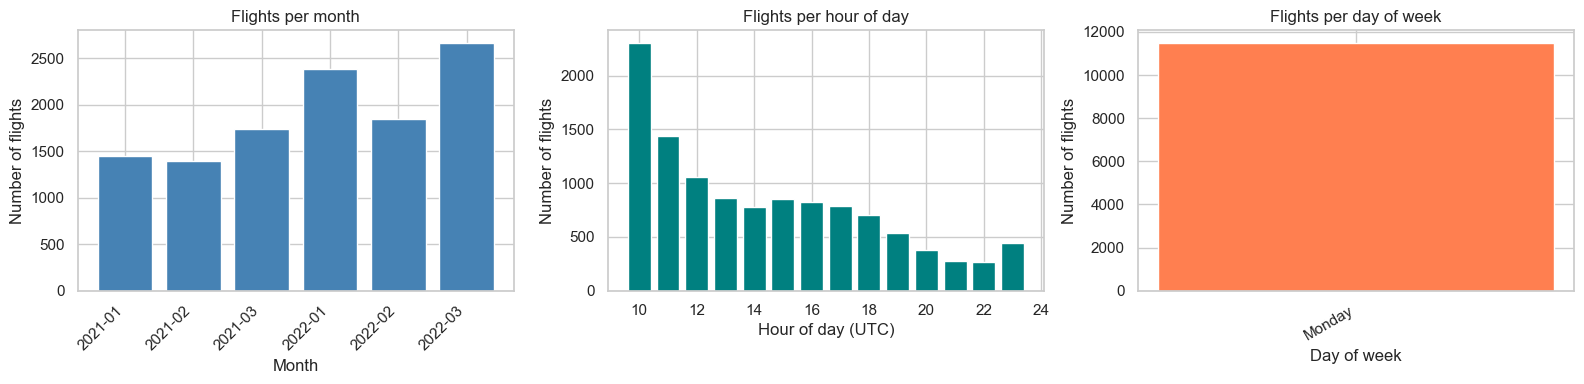

In [40]:
# Use first timestamp per flight as its "date"
flight_start = df.groupby("track_id")["datetime"].min().reset_index()
flight_start["date"]       = flight_start["datetime"].dt.date
flight_start["month"]      = flight_start["datetime"].dt.to_period("M").astype(str)
flight_start["hour"]       = flight_start["datetime"].dt.hour
flight_start["day_of_week"] = flight_start["datetime"].dt.day_name()

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Flights per month
monthly = flight_start.groupby("month").size()
axes[0].bar(monthly.index, monthly.values, color="steelblue")
axes[0].set_xticklabels(monthly.index, rotation=45, ha="right")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of flights")
axes[0].set_title("Flights per month")

# Flights per hour of day
hourly = flight_start.groupby("hour").size()
axes[1].bar(hourly.index, hourly.values, color="teal")
axes[1].set_xlabel("Hour of day (UTC)")
axes[1].set_ylabel("Number of flights")
axes[1].set_title("Flights per hour of day")

# Flights per day of week
dow = flight_start.groupby("day_of_week").size().reindex(dow_order)
axes[2].bar(dow.index, dow.values, color="coral")
axes[2].set_xticklabels(dow.index, rotation=30, ha="right")
axes[2].set_xlabel("Day of week")
axes[2].set_ylabel("Number of flights")
axes[2].set_title("Flights per day of week")

plt.tight_layout()
plt.show()

## 5. Feature Distributions (Global)

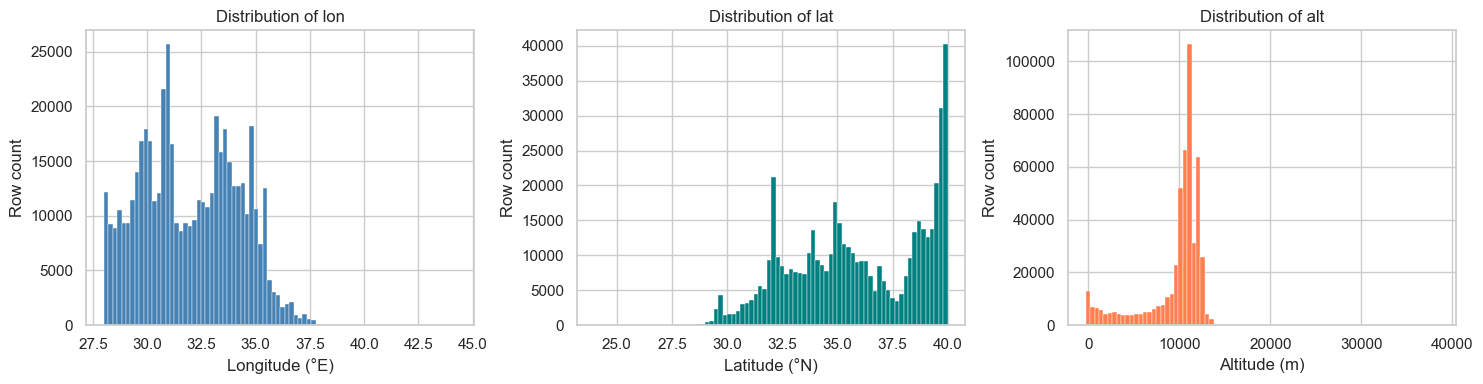

In [41]:
# Sample up to 500k rows for fast plotting
sample = df.sample(min(500_000, len(df)), random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = [("lon", "Longitude (°E)", "steelblue"),
            ("lat", "Latitude (°N)",  "teal"),
            ("alt", "Altitude (m)",   "coral")]

for ax, (col, label, color) in zip(axes, features):
    ax.hist(sample[col].dropna(), bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Row count")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_98299/3276543917.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


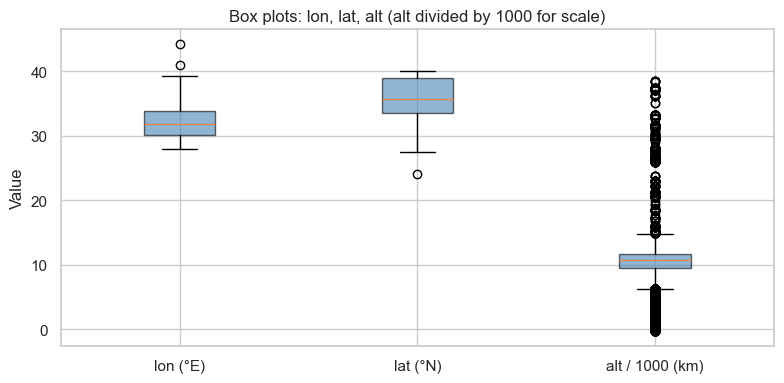

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [df["lon"].dropna(), df["lat"].dropna(), df["alt"].dropna() / 1000],
    labels=["lon (°E)", "lat (°N)", "alt / 1000 (km)"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)
ax.set_title("Box plots: lon, lat, alt (alt divided by 1000 for scale)")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## 6. Geographic Coverage

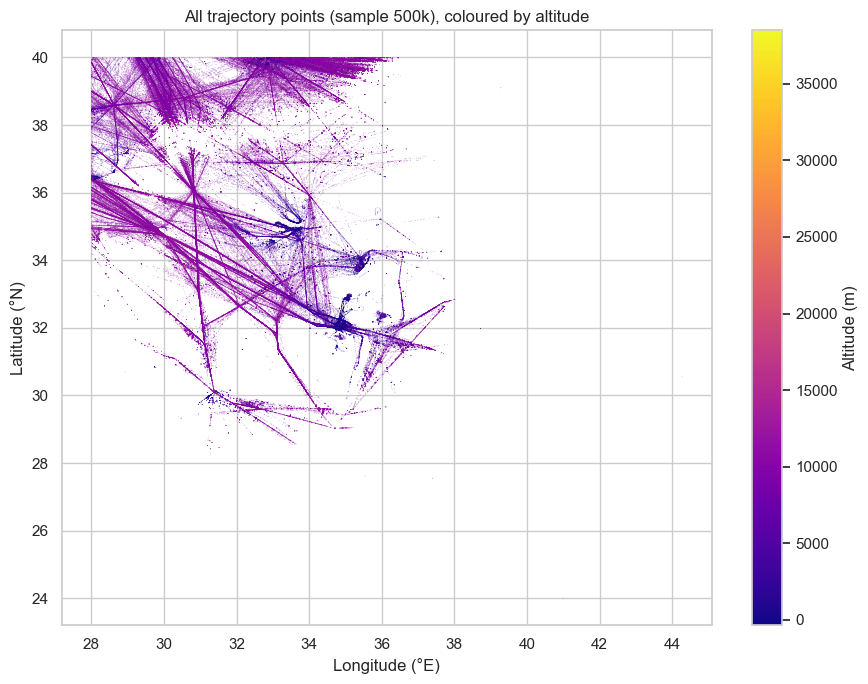

In [43]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    sample["lon"], sample["lat"],
    c=sample["alt"], cmap="plasma",
    s=0.3, alpha=0.4, linewidths=0
)
sm = plt.cm.ScalarMappable(cmap="plasma",
         norm=plt.Normalize(df["alt"].min(), df["alt"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("All trajectory points (sample 500k), coloured by altitude")
plt.tight_layout()
plt.show()

## 7. Altitude Profile

In [44]:
alt_stats = df.groupby("track_id")["alt"].agg(["min","max","mean"]).rename(
    columns={"min":"alt_min","max":"alt_max","mean":"alt_mean"})

print("=== Per-flight altitude statistics (m) ===")
print(alt_stats.describe().round(1))

=== Per-flight altitude statistics (m) ===
       alt_min  alt_max  alt_mean
count  11495.0  11495.0   11495.0
mean    7785.2  10284.5    9402.0
std     4207.7   2922.6    3066.2
min     -365.8      0.0     -25.2
25%     4621.5  10066.0    8766.0
50%     9631.7  10980.4   10517.4
75%    11262.4  11590.0   11277.6
max    14325.6  38496.2   27124.0


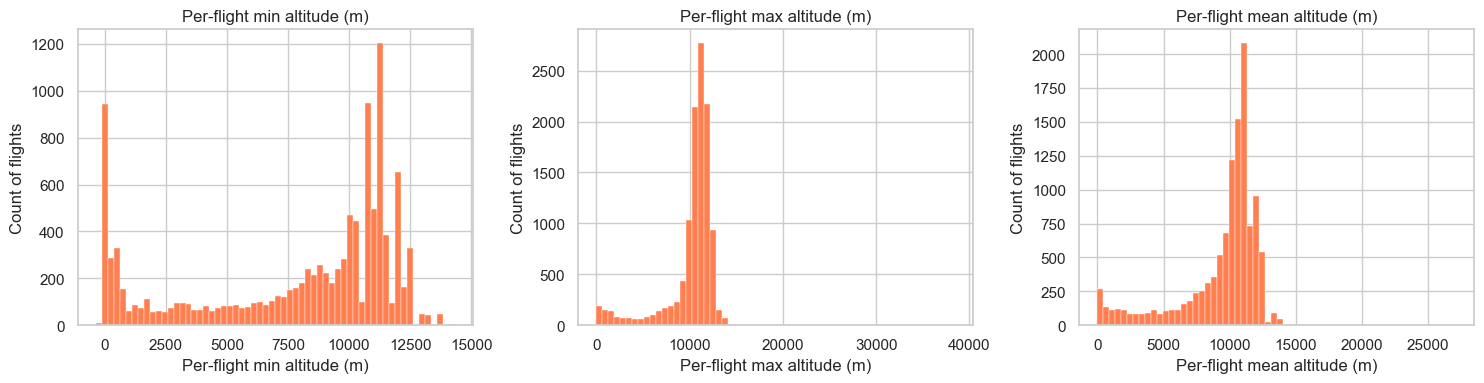

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, label) in zip(axes, [
        ("alt_min",  "Per-flight min altitude (m)"),
        ("alt_max",  "Per-flight max altitude (m)"),
        ("alt_mean", "Per-flight mean altitude (m)")]):
    ax.hist(alt_stats[col], bins=60, color="coral", edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Count of flights")
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 8. Flight Duration & Step Displacement

In [46]:
# Duration in minutes
flight_dur = df.groupby("track_id")["timestamp"].agg(lambda x: (x.max()-x.min()) / 60).rename("duration_min")

print("=== Flight duration (minutes) ===")
print(flight_dur.describe().round(1))

=== Flight duration (minutes) ===
count    11495.0
mean        20.9
std         15.4
min          0.0
25%          9.0
50%         16.5
75%         30.7
max         59.7
Name: duration_min, dtype: float64


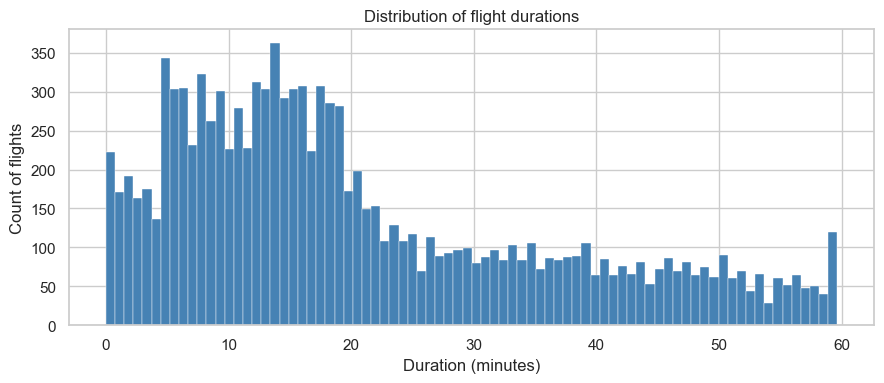

In [47]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(flight_dur.values, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Count of flights")
ax.set_title("Distribution of flight durations")
plt.tight_layout()
plt.show()

In [48]:
# Step-to-step displacement in degrees (Euclidean lon-lat)
# Compute on a sample of flights for speed
sample_ids = rng.choice(df["track_id"].unique(), size=min(500, n_flights), replace=False)
sub = df[df["track_id"].isin(sample_ids)].copy()
sub = sub.sort_values(["track_id","timestamp"])

sub["dlon"] = sub.groupby("track_id")["lon"].diff()
sub["dlat"] = sub.groupby("track_id")["lat"].diff()
sub["dalt"] = sub.groupby("track_id")["alt"].diff()
sub["disp"] = np.sqrt(sub["dlon"]**2 + sub["dlat"]**2)

print("=== Step-to-step displacement (degrees) — 500 sampled flights ===")
print(sub[["dlon","dlat","dalt","disp"]].describe().round(5))

=== Step-to-step displacement (degrees) — 500 sampled flights ===
              dlon         dlat         dalt         disp
count  62710.00000  62710.00000  62710.00000  62710.00000
mean       0.00665     -0.00466     -1.62303      0.01975
std        0.04241      0.04473    251.91993      0.05895
min       -3.27631     -3.38542 -12268.20000      0.00000
25%        0.00000     -0.01429      0.00000      0.00000
50%        0.00000      0.00000      0.00000      0.02049
75%        0.01865      0.00000      0.00000      0.02527
max        2.96471      2.06451  12268.20000      4.20138


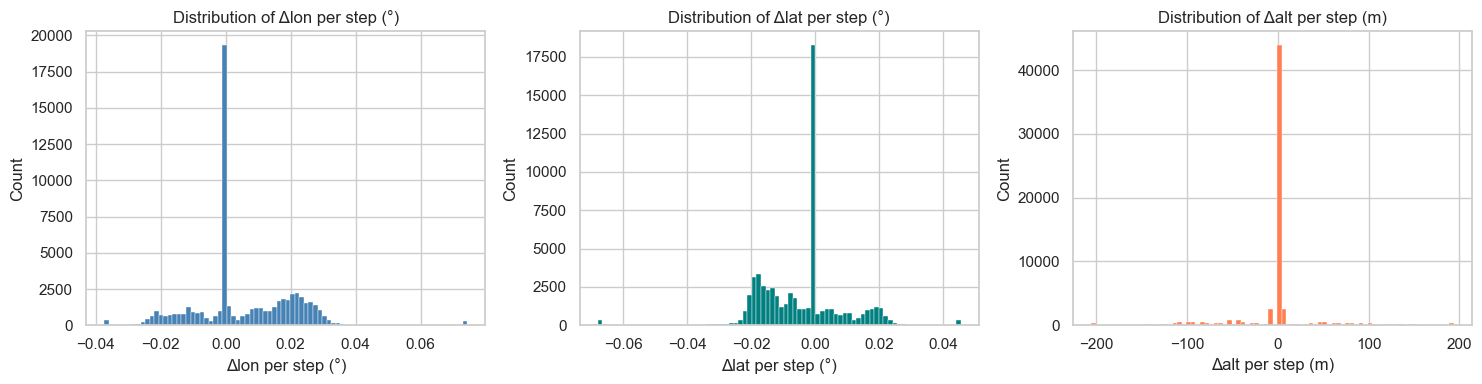

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, label, color) in zip(axes, [
        ("dlon", "Δlon per step (°)",  "steelblue"),
        ("dlat", "Δlat per step (°)",  "teal"),
        ("dalt", "Δalt per step (m)",  "coral")]):
    vals = sub[col].dropna()
    lo, hi = vals.quantile(0.005), vals.quantile(0.995)  # clip outliers
    ax.hist(vals.clip(lo, hi), bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")

plt.tight_layout()
plt.show()

## 9. Filtering: MIN_LENGTH = 200

In [50]:
kept    = flight_len[flight_len >= MIN_LENGTH]
dropped = flight_len[flight_len <  MIN_LENGTH]

print(f"Flights kept    : {len(kept):,}  ({100*len(kept)/len(flight_len):.1f}%)")
print(f"Flights dropped : {len(dropped):,}  ({100*len(dropped)/len(flight_len):.1f}%)")
print()
print("Kept flight length summary:")
print(kept.describe().round(1))

Flights kept    : 2,361  (20.5%)
Flights dropped : 9,134  (79.5%)

Kept flight length summary:
count    2361.0
mean      267.8
std        44.3
min       200.0
25%       230.0
50%       264.0
75%       302.0
max       359.0
Name: n_steps, dtype: float64


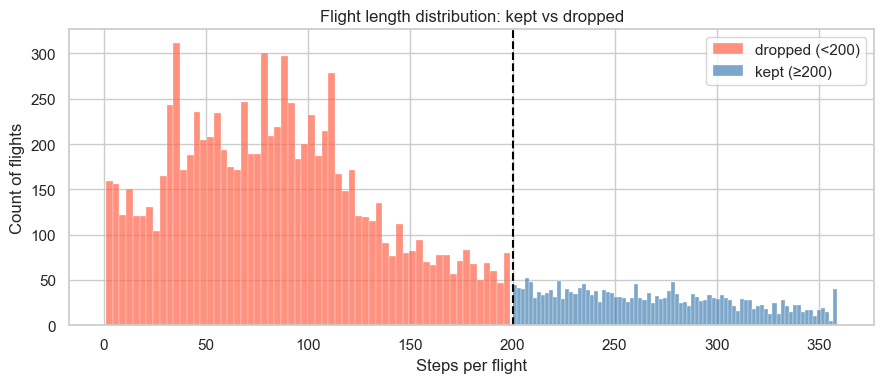

In [51]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dropped.values, bins=60, color="tomato",    alpha=0.7, label=f"dropped (<{MIN_LENGTH})", edgecolor="white", linewidth=0.3)
ax.hist(kept.values,    bins=80, color="steelblue", alpha=0.7, label=f"kept (≥{MIN_LENGTH})",    edgecolor="white", linewidth=0.3)
ax.axvline(MIN_LENGTH, color="black", linestyle="--")
ax.set_xlabel("Steps per flight")
ax.set_ylabel("Count of flights")
ax.set_title("Flight length distribution: kept vs dropped")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

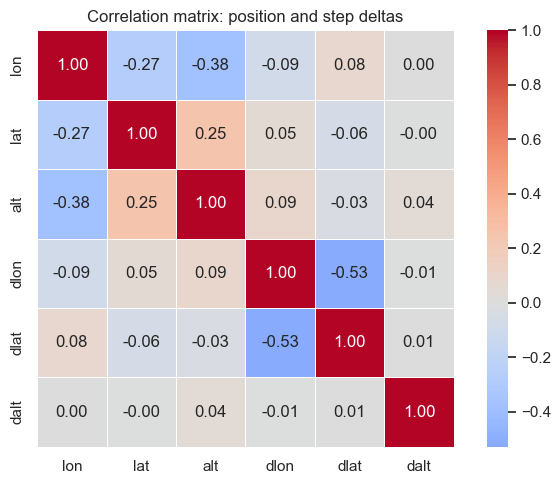

In [52]:
corr_df = sub[["lon","lat","alt","dlon","dlat","dalt"]].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix: position and step deltas")
plt.tight_layout()
plt.show()

## 11. Sample Flight Trajectories

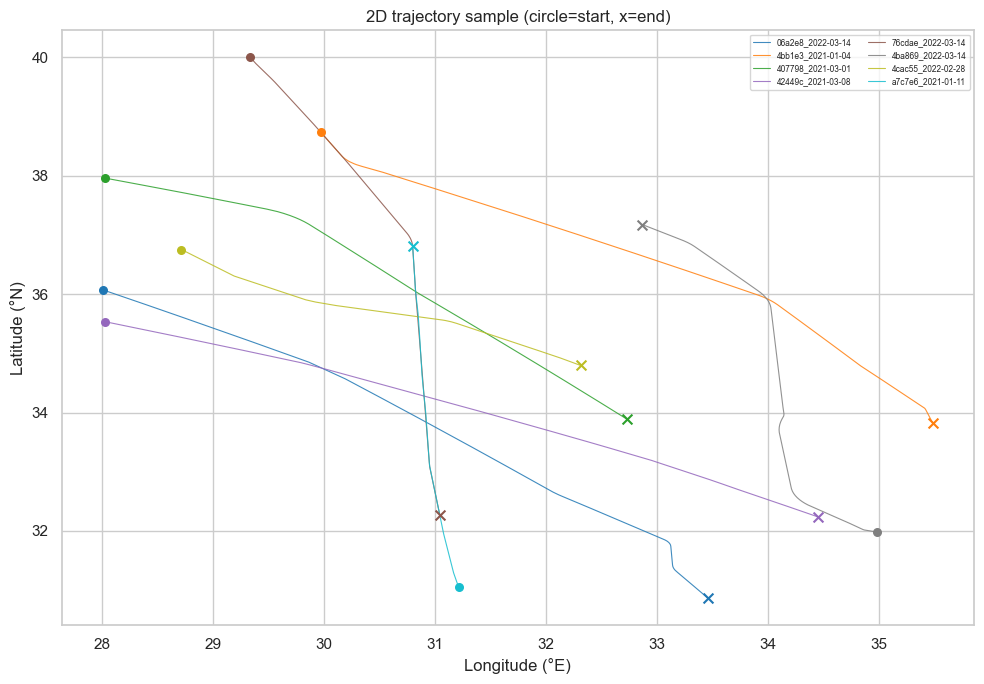

In [53]:
# Pick 8 random flights from the kept set
plot_ids = rng.choice(kept.index.values, size=8, replace=False)
colors   = cm.tab10(np.linspace(0, 1, len(plot_ids)))

# 2D: lon vs lat
fig, ax = plt.subplots(figsize=(10, 7))
for tid, color in zip(plot_ids, colors):
    traj = df[df["track_id"] == tid].sort_values("timestamp")
    ax.plot(traj["lon"], traj["lat"], color=color, linewidth=0.8, alpha=0.85, label=tid)
    ax.scatter(traj["lon"].iloc[0],  traj["lat"].iloc[0],  color=color, marker="o", s=30, zorder=5)
    ax.scatter(traj["lon"].iloc[-1], traj["lat"].iloc[-1], color=color, marker="x", s=50, zorder=5)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("2D trajectory sample (circle=start, x=end)")
ax.legend(fontsize=6, loc="best", ncol=2)
plt.tight_layout()
plt.show()

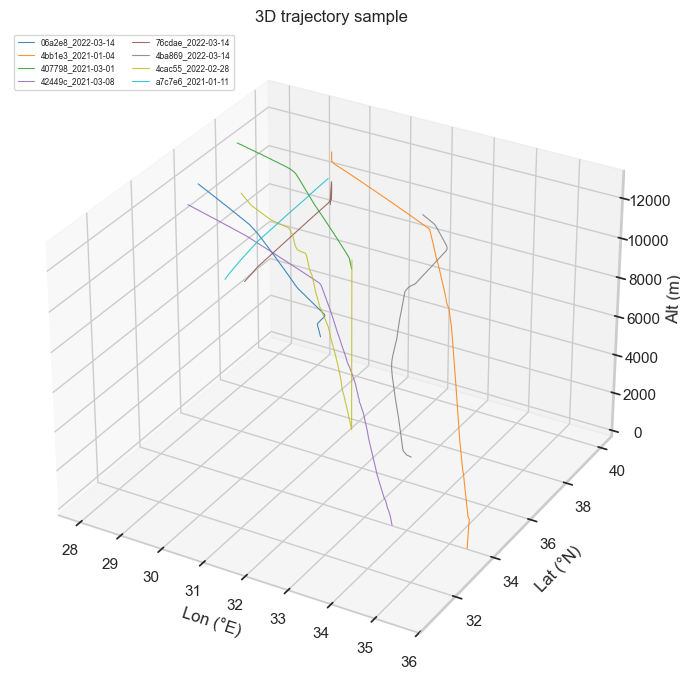

In [54]:
# 3D: lon, lat, alt
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection="3d")
for tid, color in zip(plot_ids, colors):
    traj = df[df["track_id"] == tid].sort_values("timestamp")
    ax.plot(traj["lon"].values, traj["lat"].values, traj["alt"].values,
            color=color, linewidth=0.8, alpha=0.85, label=tid)
ax.set_xlabel("Lon (°E)")
ax.set_ylabel("Lat (°N)")
ax.set_zlabel("Alt (m)")
ax.set_title("3D trajectory sample")
ax.legend(fontsize=6, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

## 12. Altitude Profile Over Time (sample flights)

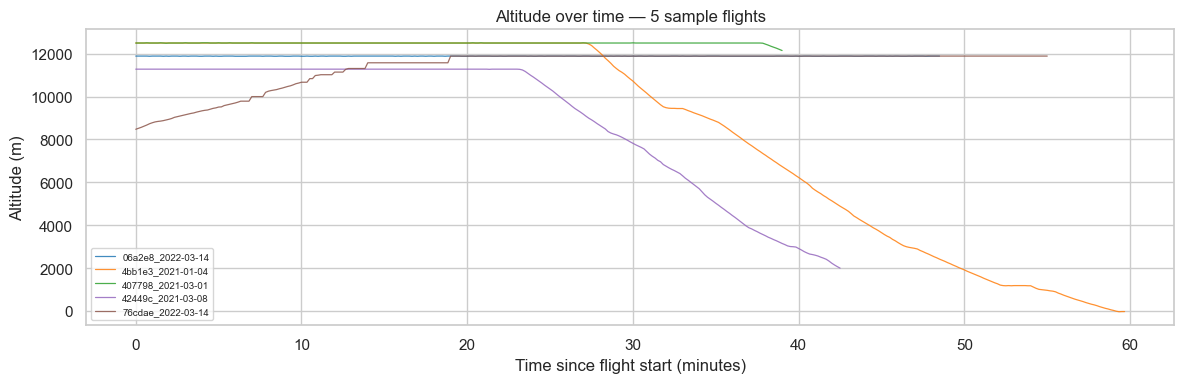

In [55]:
fig, ax = plt.subplots(figsize=(12, 4))
for tid, color in zip(plot_ids[:5], colors[:5]):
    traj = df[df["track_id"] == tid].sort_values("timestamp").reset_index(drop=True)
    ax.plot(traj.index * 10 / 60, traj["alt"], color=color, linewidth=0.9, alpha=0.85, label=tid)
ax.set_xlabel("Time since flight start (minutes)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Altitude over time — 5 sample flights")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 13. Summary Statistics Table

In [56]:
summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Unique flights (total)",
        f"Flights kept (≥{MIN_LENGTH} steps)",
        f"Flights dropped (<{MIN_LENGTH} steps)",
        "Date range start",
        "Date range end",
        "Sampling interval",
        "Longitude range",
        "Latitude range",
        "Altitude range (m)",
        "Median flight duration (min)",
        "Median flight length (steps)",
    ],
    "Value": [
        f"{len(df):,}",
        f"{n_flights:,}",
        f"{len(kept):,}",
        f"{len(dropped):,}",
        str(date_min.date()),
        str(date_max.date()),
        "10 seconds",
        f"[{df['lon'].min():.2f}, {df['lon'].max():.2f}]",
        f"[{df['lat'].min():.2f}, {df['lat'].max():.2f}]",
        f"[{df['alt'].min():.0f}, {df['alt'].max():.0f}]",
        f"{flight_dur.median():.1f}",
        f"{flight_len.median():.0f}",
    ]
})

summary.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Metric,Value
Total rows,"1,403,610"
Unique flights (total),"11,495"
Flights kept (≥200 steps),"2,361"
Flights dropped (<200 steps),"9,134"
Date range start,2021-01-04
Date range end,2022-03-28
Sampling interval,10 seconds
Longitude range,"[28.00, 44.27]"
Latitude range,"[24.00, 40.00]"
Altitude range (m),"[-366, 38496]"


In [57]:
df.columns

Index(['track_id', 'lon', 'lat', 'alt', 'timestamp', 'datetime'], dtype='object')

In [58]:
import pandas as pd
import numpy as np

def split_flights(df, flight_id_col="track_id", n_test_flights=100, random_state=42):
    
    np.random.seed(random_state)

    # unique flights
    flights = df[flight_id_col].unique()

    # sample flights for test
    test_flights = np.random.choice(
        flights,
        size=min(n_test_flights, len(flights)),
        replace=False
    )

    # split dataset
    test_df = df[df[flight_id_col].isin(test_flights)].copy()
    train_df = df[~df[flight_id_col].isin(test_flights)].copy()

    return train_df, test_df, test_flights

In [62]:
train_df, test_df, test_flights = split_flights(
    df,
    flight_id_col="track_id",
    n_test_flights=100
)

print(len(train_df), len(test_df))
len(train_df["track_id"].unique()), len(test_df["track_id"].unique())

1391511 12099


(11395, 100)

In [63]:
train_df.to_parquet("../data/train_df.parquet", index=False)
test_df.to_parquet("../data/test_df.parquet", index=False)

print(f"train_df saved: {len(train_df):,} rows")
print(f"test_df saved : {len(test_df):,} rows")

train_df saved: 1,391,511 rows
test_df saved : 12,099 rows
